# Heart Failure Prediction — Exploratory Data Analysis

## Introduction

Cardiovascular disease (CVD) is considered to be one of the leading cause of death globally. The majority of which happens are due to heart attacks and strokes. Early detection and identification of high-risk individuals can save lives, which is exactly where machine learning can play a crucial role.

In this notebook  a Heart Failure Prediction Dataset assembled from five independent clinical studies will be explored. The data contains data from 918 patients with 11 clinical features and a binary target variable indicating whether the patient has heart disease.

Dataset source: [Kaggle — Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)


## 1. Data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
PALETTE = ['#66c2a5', '#fc8d62']
PALETTE_CAT = sns.color_palette('Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv('heart.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 918 rows × 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0



## 2. Feature Dictionary
It is important to understand what each variable actually means. Here is the dictionary for the features presented in the dataset. 

| Feature | Type | Description |
|---|---|---|
| **Age** | Numeric | Patient age in years |
| **Sex** | Categorical | Biological sex: `M` = Male, `F` = Female |
| **ChestPainType** | Categorical | Type of chest pain: `TA` = Typical Angina, `ATA` = Atypical Angina, `NAP` = Non-Anginal Pain, `ASY` = Asymptomatic |
| **RestingBP** | Numeric | Resting blood pressure (mm Hg) at hospital admission |
| **Cholesterol** | Numeric | Serum cholesterol (mm/dl) — **note: 0 values indicate missing data** |
| **FastingBS** | Binary | Fasting blood sugar: `1` if > 120 mg/dl (diabetic threshold), `0` otherwise |
| **RestingECG** | Categorical | Resting ECG results: `Normal`, `ST` (ST-T wave abnormality), `LVH` (left ventricular hypertrophy) |
| **MaxHR** | Numeric | Maximum heart rate achieved during exercise |
| **ExerciseAngina** | Binary | Exercise-induced angina: `Y` = Yes, `N` = No |
| **Oldpeak** | Numeric | ST depression induced by exercise relative to rest (indicator of ischemia) |
| **ST_Slope** | Categorical | Slope of peak exercise ST segment: `Up`, `Flat`, `Down` |
| **HeartDisease** | Binary (**Target**) | `1` = heart disease present, `0` = normal |




Most features come from a stress test (exercise ECG), which is a standard diagnostic procedure. The patient walks on a treadmill while their ECG, blood pressure and heart rate are monitored. Key indicators of heart disease include:
- ST depression (Oldpeak) = a flattening or downward shift of the ECG wave during exercise, signalling that heart muscle isn't getting enough blood
- ST slope = the direction of that shift
- Exercise-induced angina = chest pain that appears only under physical stress
- Maximum heart rate = diseased hearts often can't reach high rates under load
## 3. Data quality assessment

### 3.1 Structure of data

In [34]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,MaxHR_Age_ratio,Oldpeak_log1p
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,4.300000,1.280934
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,3.183673,1.526056
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,2.648649,1.280934
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,2.250000,1.629241
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,2.259259,1.280934


In [35]:
print('Data Types & Non-Null Counts')
df.info()
print('\n Summary Statistics')
df.describe().round(2)

Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              918 non-null    int64  
 1   Sex              918 non-null    object 
 2   ChestPainType    918 non-null    object 
 3   RestingBP        918 non-null    int64  
 4   Cholesterol      918 non-null    int64  
 5   FastingBS        918 non-null    int64  
 6   RestingECG       918 non-null    object 
 7   MaxHR            918 non-null    int64  
 8   ExerciseAngina   918 non-null    object 
 9   Oldpeak          918 non-null    float64
 10  ST_Slope         918 non-null    object 
 11  HeartDisease     918 non-null    int64  
 12  MaxHR_Age_ratio  918 non-null    float64
 13  Oldpeak_log1p    918 non-null    float64
dtypes: float64(3), int64(6), object(5)
memory usage: 100.5+ KB

 Summary Statistics


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,MaxHR_Age_ratio,Oldpeak_log1p
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55,2.68,1.48
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50,0.89,0.23
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00,1.03,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00,2.06,1.28
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00,2.51,1.44
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00,3.16,1.63
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00,6.97,2.28


### 3.2 Checking for missing values
At the first glance there are no missing values, but often in medical datasets missing measurements can be encoded as 0 rather than NaN. This has to be checked carefully.

In [29]:
nan_counts = df.isnull().sum()
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
zero_counts  = (df[numeric_cols] == 0).sum()

quality = pd.DataFrame({
    'NaN count':  nan_counts[numeric_cols],
    'Zero count': zero_counts,
    'Zero %':     (zero_counts / len(df) * 100).round(1)
})
print(quality)



             NaN count  Zero count  Zero %
Age                  0           0     0.0
RestingBP            0           1     0.1
Cholesterol          0         172    18.7
MaxHR                0           0     0.0
Oldpeak              0         368    40.1


Cholesterol has 172 zero values (18.7% of rows). these are probably missing measurements and not true zero cholesterol.
RestingBP has 1 zero value, which is physiologically impossible.

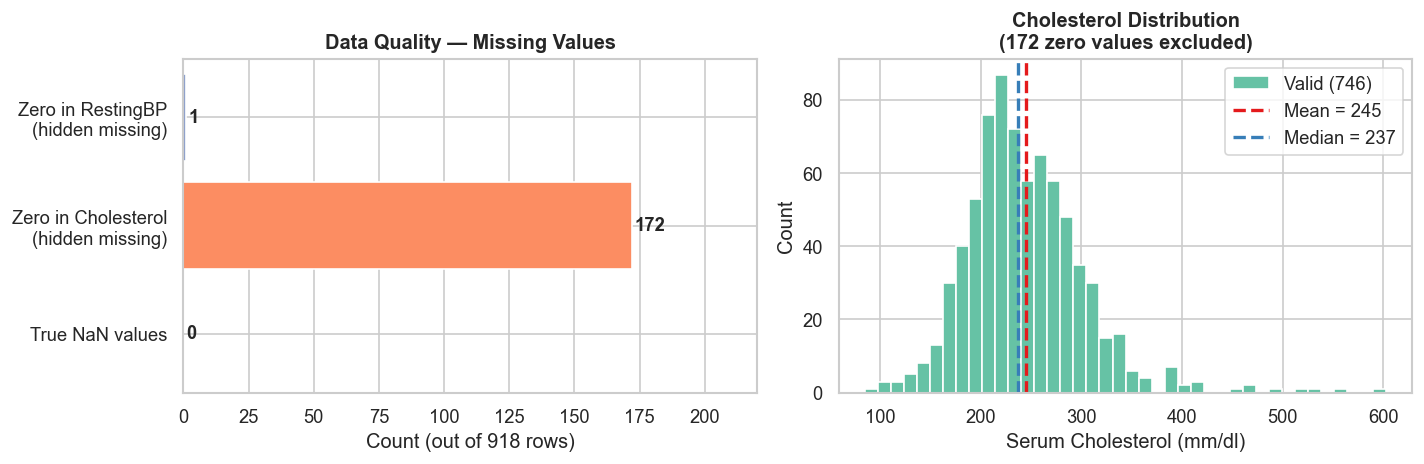


Cholesterol (valid values only):
count    746.0
mean     244.6
std       59.2
min       85.0
25%      207.2
50%      237.0
75%      275.0
max      603.0
Name: Cholesterol, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

categories  = ['True NaN values', 'Zero in Cholesterol\n(hidden missing)', 'Zero in RestingBP\n(hidden missing)']
values      = [0, 172, 1]
colors      = ['#66c2a5', '#fc8d62', '#8da0cb']
bars = axes[0].barh(categories, values, color=colors, edgecolor='white')
for bar, v in zip(bars, values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(v), va='center', fontweight='bold')
axes[0].set_xlabel('Count (out of 918 rows)')
axes[0].set_title('Data Quality — Missing Values', fontweight='bold')
axes[0].set_xlim(0, 220)
chol_valid   = df[df['Cholesterol'] > 0]['Cholesterol']
chol_missing = df[df['Cholesterol'] == 0]

axes[1].hist(chol_valid, bins=40, color='#66c2a5', edgecolor='white', label=f'Valid ({len(chol_valid)})')
axes[1].axvline(chol_valid.mean(), color='#e41a1c', lw=2, linestyle='--', label=f'Mean = {chol_valid.mean():.0f}')
axes[1].axvline(chol_valid.median(), color='#377eb8', lw=2, linestyle='--', label=f'Median = {chol_valid.median():.0f}')
axes[1].set_title(f'Cholesterol Distribution\n(172 zero values excluded)', fontweight='bold')
axes[1].set_xlabel('Serum Cholesterol (mm/dl)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nCholesterol (valid values only):')
print(chol_valid.describe().round(1))

We see that Cholesterol has 172 zero entries (18.7%). So we will need to impute these before modelling (either mean/median imputation or model-based). RestingBP has one impossible zero that should be also removed or imputed.

### 3.3 Detection of outliers

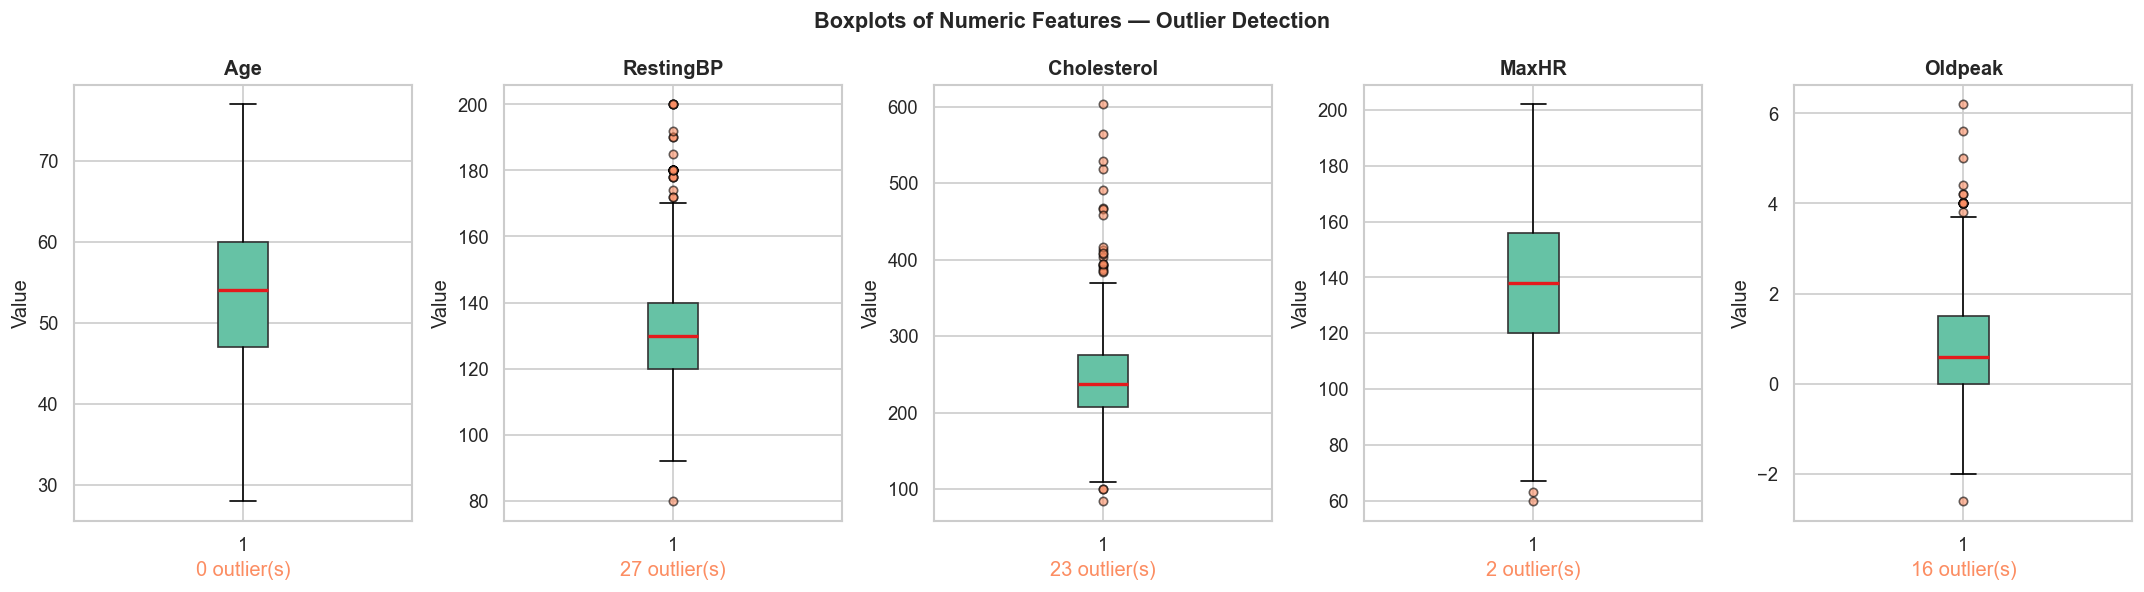

In [11]:
df_clean = df.copy()
df_clean.loc[df_clean['Cholesterol'] == 0, 'Cholesterol'] = np.nan
df_clean.loc[df_clean['RestingBP']   == 0, 'RestingBP']   = np.nan

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    data_col = df_clean[col].dropna()
    ax.boxplot(data_col, patch_artist=True,
               boxprops=dict(facecolor='#66c2a5', color='#333'),
               medianprops=dict(color='#e41a1c', lw=2),
               flierprops=dict(marker='o', markerfacecolor='#fc8d62', markersize=5, alpha=0.6))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')

    Q1, Q3 = data_col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    out_count = ((data_col < Q1 - 1.5*IQR) | (data_col > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'{out_count} outlier(s)', color='#fc8d62')

fig.suptitle('Boxplots of Numeric Features — Outlier Detection', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()



- Cholesterol has a number of high values (up to 603 mm/dl). While extreme, such levels are medically documented in familial hypercholesterolaemia - not necessarily errors.
- Oldpeak has negative values (ST elevation rather than depression). These are rare but physiologically valid.
- RestingBP has one extremely high value (~200 mm Hg) that could be a hypertensive crisis entry or a measurement error.
- MaxHR shows a few unusually low values. These may reflect older patients or those with severe disease and warrant medical review before removal.

## 4. Target Variable Distribution

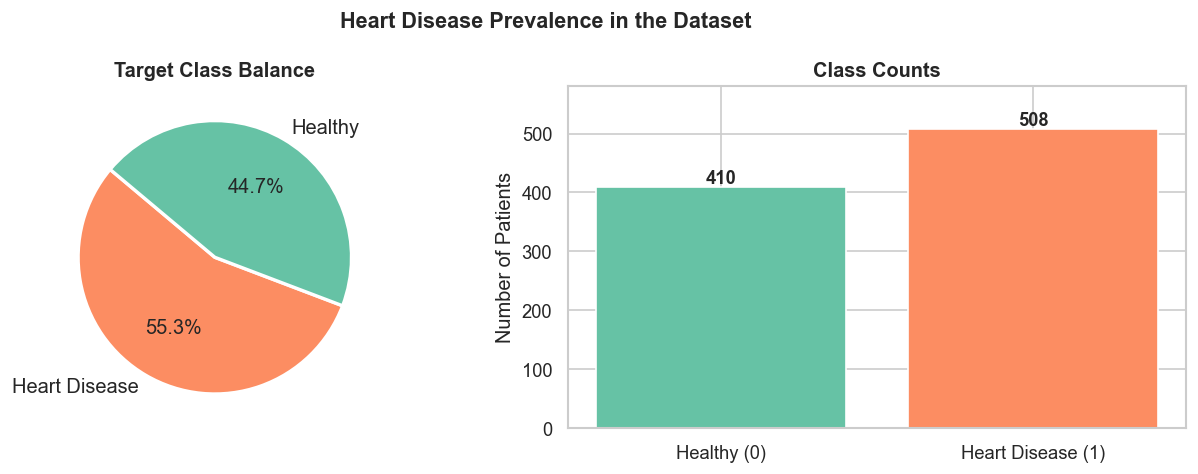

Healthy: 410 patients (44.7%)
Heart Disease: 508 patients (55.3%)


In [12]:
target_counts = df['HeartDisease'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(
    target_counts,
    labels=['Heart Disease', 'Healthy'],
    colors=[PALETTE[1], PALETTE[0]],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
axes[0].set_title('Target Class Balance', fontweight='bold')

bars = axes[1].bar(['Healthy (0)', 'Heart Disease (1)'],
                   target_counts[[0, 1]], color=[PALETTE[0], PALETTE[1]], edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', fontweight='bold')
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Class Counts', fontweight='bold')
axes[1].set_ylim(0, 580)

plt.suptitle('Heart Disease Prevalence in the Dataset', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Healthy: {target_counts[0]} patients ({target_counts[0]/len(df)*100:.1f}%)')
print(f'Heart Disease: {target_counts[1]} patients ({target_counts[1]/len(df)*100:.1f}%)')

The dataset is slightly imbalanced but manageable for further analysis.
## 5. Univariate analysis and feature distributions

### 5.1 Numerical features

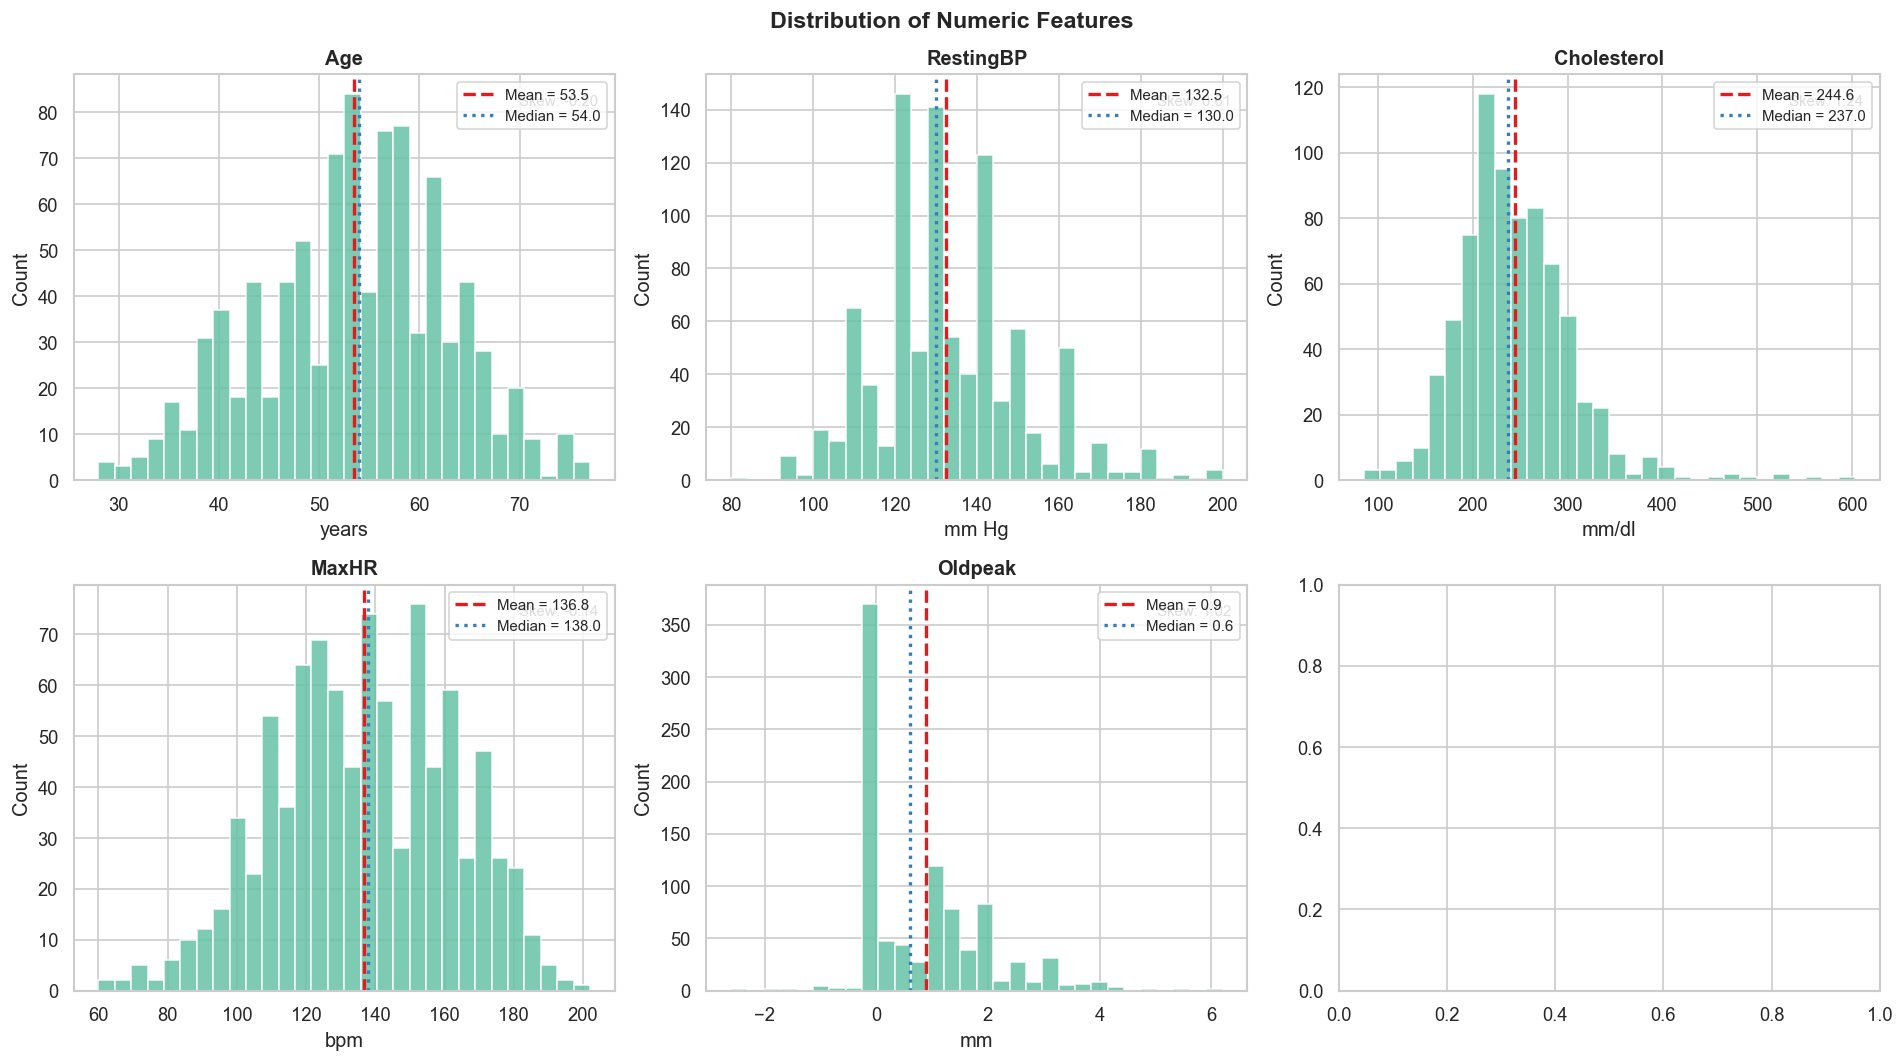

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
units = ['years', 'mm Hg', 'mm/dl', 'bpm', 'mm']

for i, (col, unit) in enumerate(zip(num_features, units)):
    data_plot = df_clean[col].dropna()
    axes[i].hist(data_plot, bins=30, color='#66c2a5', edgecolor='white', alpha=0.85)
    axes[i].axvline(data_plot.mean(),   color='#e41a1c', lw=2, linestyle='--', label=f'Mean = {data_plot.mean():.1f}')
    axes[i].axvline(data_plot.median(), color='#377eb8', lw=2, linestyle=':',  label=f'Median = {data_plot.median():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(unit)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)
    
    skew = data_plot.skew()
    axes[i].text(0.97, 0.95, f'Skew: {skew:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9, color='#555')


fig.suptitle('Distribution of Numeric Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


- Age: Slightly left-skewed, most patients are between 45 and 65 years.
- RestingBP: Roughly normally distributed around 130 mm Hg.
- Cholesterol: Right-skewed with a long tail. The mean (~244 mm/dl) is above the borderline high clinical threshold of 200 mm/dl.
- MaxHR: Left-skewed; most patients achieve moderate-to-good rates, but a tail of low achievers exists, often the one affected with disease.
- Oldpeak: Strongly right-skewed; many patients show zero or near-zero ST depression, while a minority show significant depression, which is an indicator of ischemia.

### 5.2 Categorical features

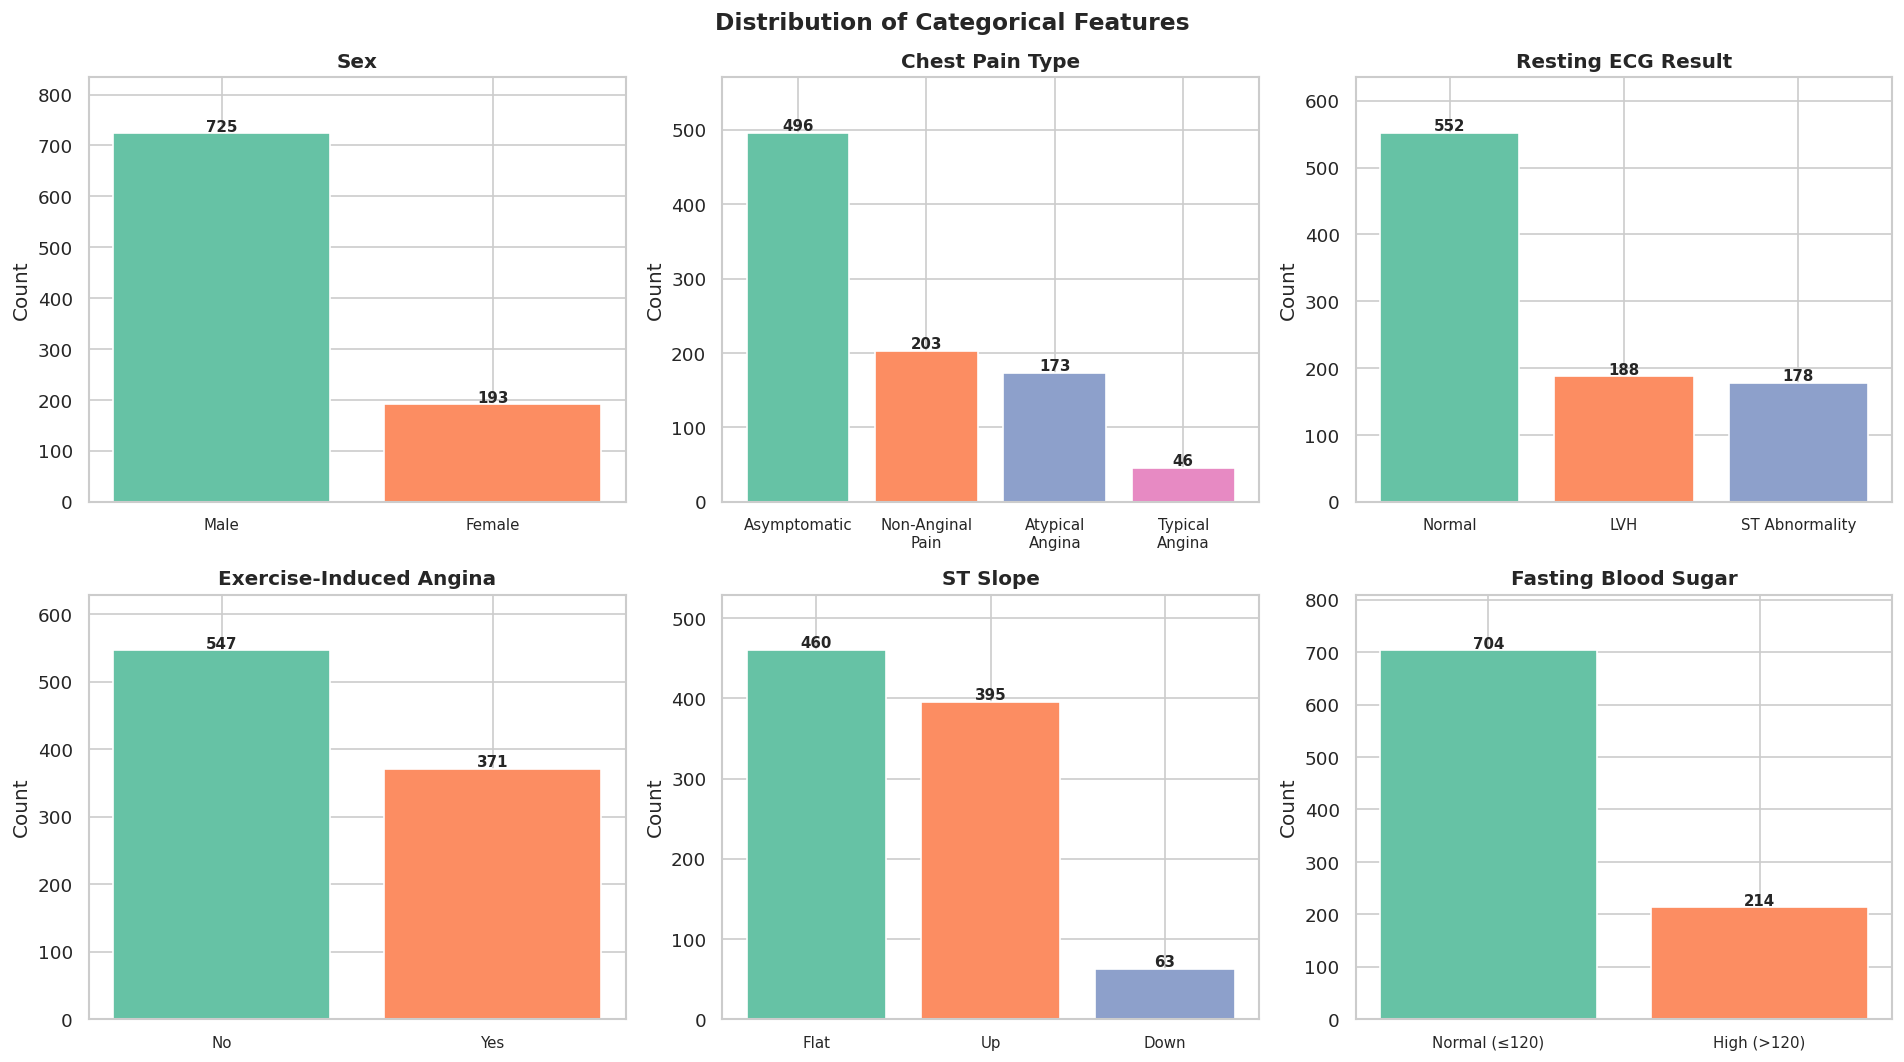

In [8]:
cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_labels = {
    'Sex':            {'M': 'Male', 'F': 'Female'},
    'ChestPainType':  {'ASY': 'Asymptomatic', 'NAP': 'Non-Anginal\nPain', 'ATA': 'Atypical\nAngina', 'TA': 'Typical\nAngina'},
    'RestingECG':     {'Normal': 'Normal', 'LVH': 'LVH', 'ST': 'ST Abnormality'},
    'ExerciseAngina': {'N': 'No', 'Y': 'Yes'},
    'ST_Slope':       {'Flat': 'Flat', 'Up': 'Up', 'Down': 'Down'},
    'FastingBS':      {0: 'Normal (≤120)', 1: 'High (>120)'}
}
cat_titles = {
    'Sex':            'Sex',
    'ChestPainType':  'Chest Pain Type',
    'RestingECG':     'Resting ECG Result',
    'ExerciseAngina': 'Exercise-Induced Angina',
    'ST_Slope':       'ST Slope',
    'FastingBS':      'Fasting Blood Sugar'
}

for i, col in enumerate(cat_features):
    vc = df[col].value_counts()
    bars = axes[i].bar(range(len(vc)), vc.values,
                       color=PALETTE_CAT[:len(vc)], edgecolor='white')
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels([cat_labels[col].get(k, str(k)) for k in vc.index], fontsize=9)
    axes[i].set_title(cat_titles[col], fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     f'{int(bar.get_height())}', ha='center', fontsize=9, fontweight='bold')
    axes[i].set_ylim(0, vc.max() * 1.15)

fig.suptitle('Distribution of Categorical Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


- Sex: The dataset is heavily male-skewed (79% male).
- Chest Pain Type: The most common type is Asymptomatic. 
- RestingECG: The majority are normal, but ~40% show ST or LVH abnormalities.
- Exercise Angina: About 40% of patients experience angina during exercise.
- ST Slope: Flat slope is the most common.
- Fasting Blood Sugar: About 23% of patients have high fasting blood sugar, indicating diabetes or pre-diabetes (that's a high risk factor)

## 6. Bivariate analysis 

### 6.1 Numerical features

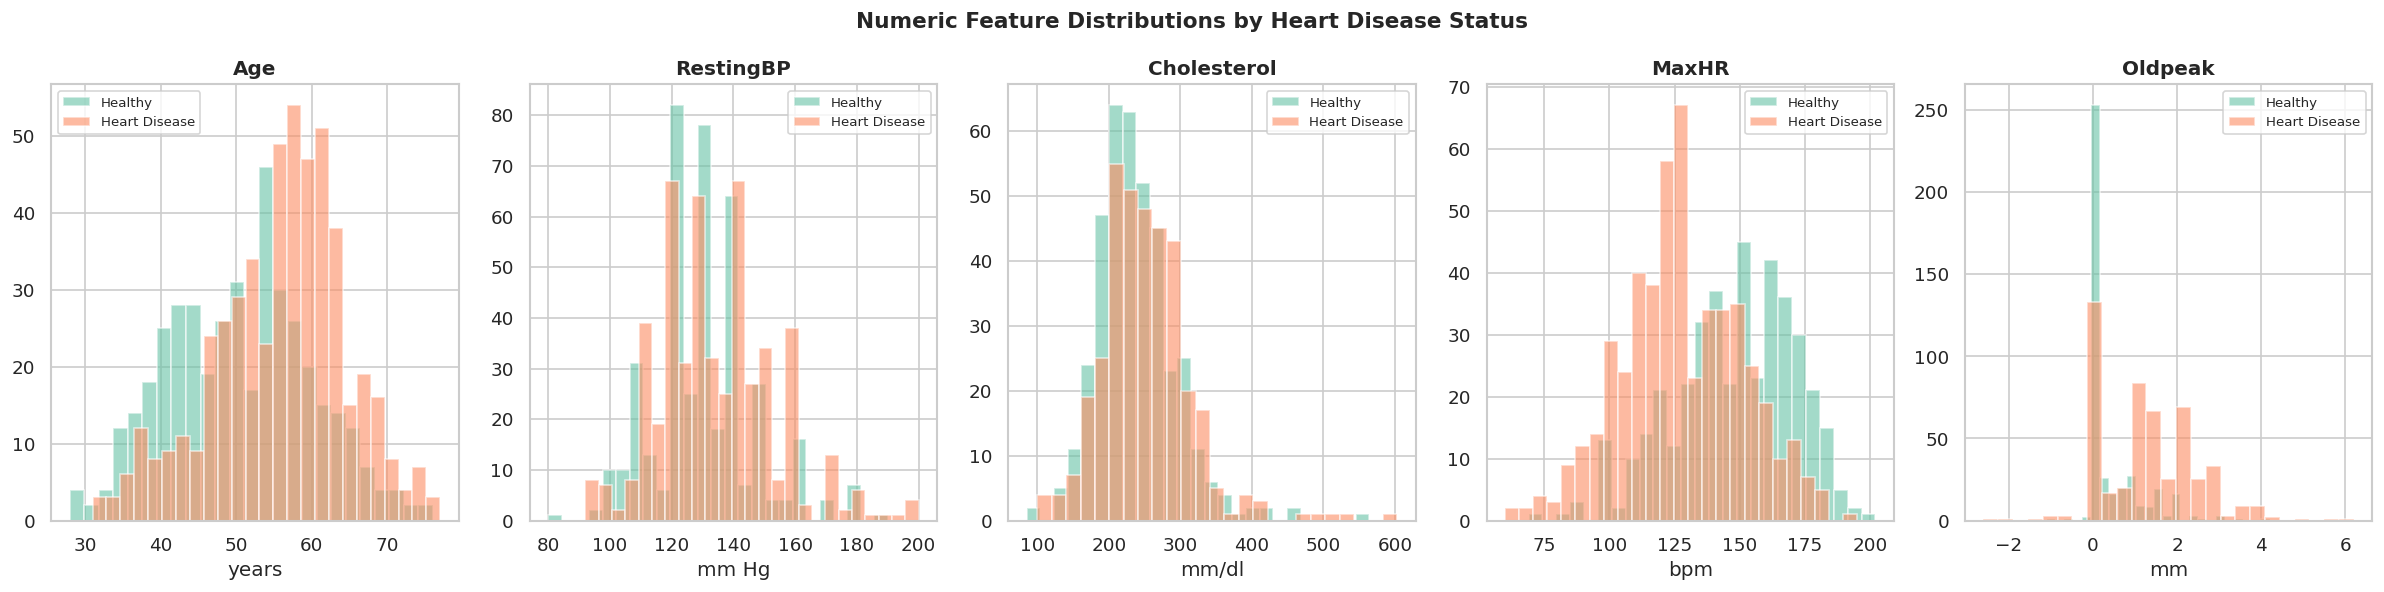

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (col, unit) in zip(axes, zip(num_features, units)):
    for hd, label, color in zip([0, 1], ['Healthy', 'Heart Disease'], PALETTE):
        vals = df_clean[df_clean['HeartDisease'] == hd][col].dropna()
        ax.hist(vals, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(unit)
    ax.legend(fontsize=8)

fig.suptitle('Numeric Feature Distributions by Heart Disease Status', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

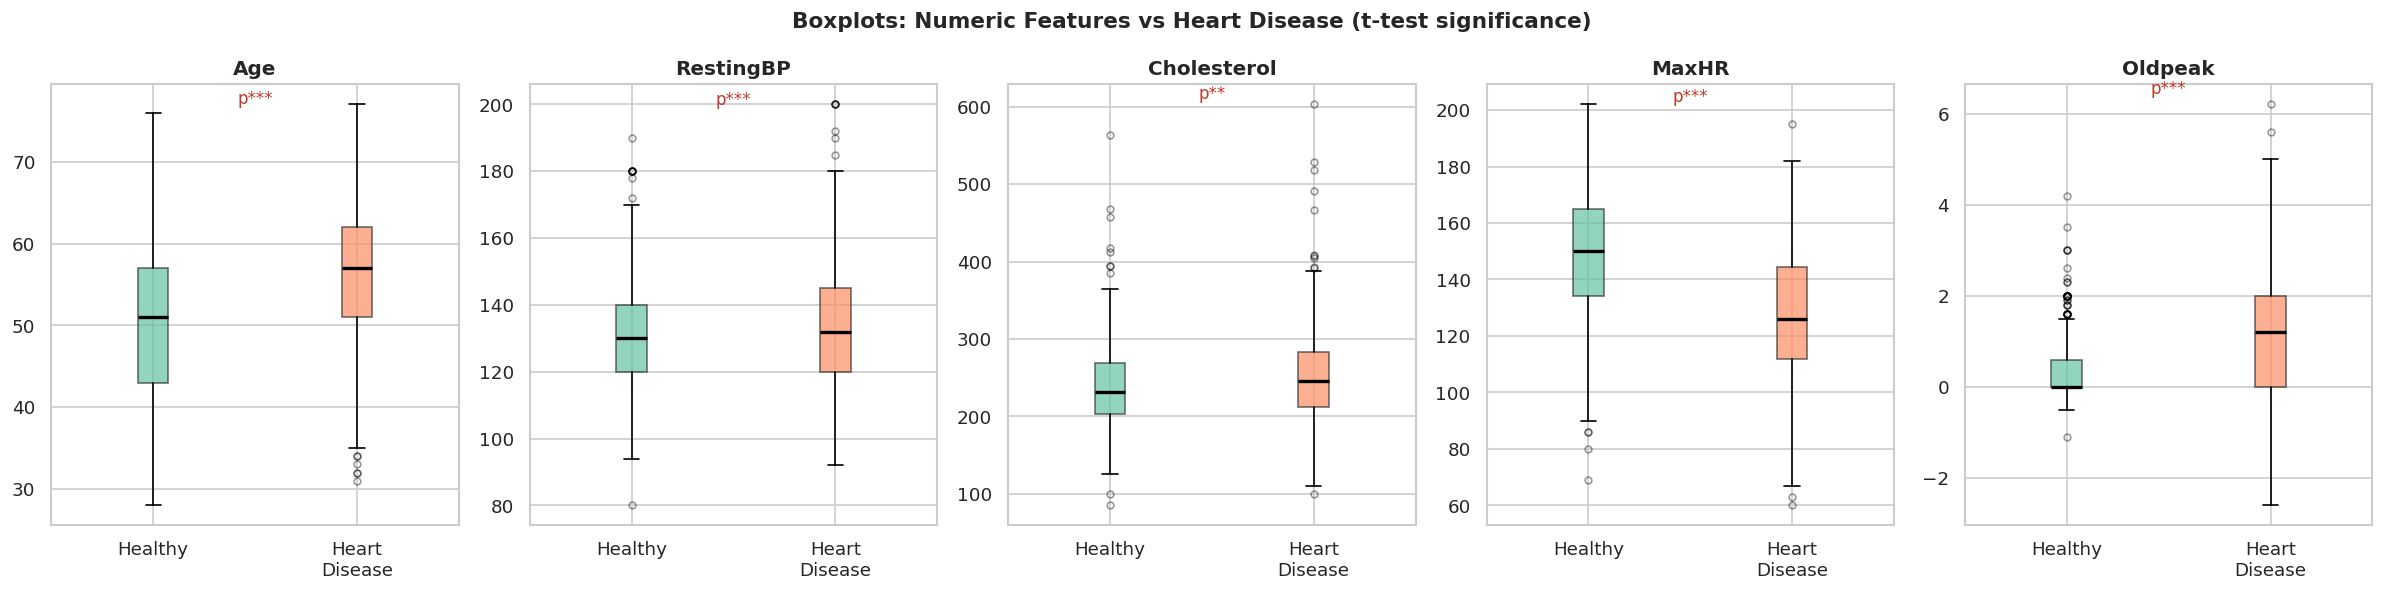


Mean values by group:
                Age  RestingBP  Cholesterol   MaxHR  Oldpeak
HeartDisease                                                
0             50.55     130.18       238.77  148.15     0.41
1             55.90     134.45       251.06  127.66     1.27


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

healthy  = df_clean[df_clean['HeartDisease'] == 0]
diseased = df_clean[df_clean['HeartDisease'] == 1]

for ax, col in zip(axes, num_features):
    data_to_plot = [healthy[col].dropna(), diseased[col].dropna()]
    bp = ax.boxplot(data_to_plot, patch_artist=True,
                    boxprops=dict(color='#333'),
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.4))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Healthy', 'Heart\nDisease'])
    ax.set_title(col, fontweight='bold')
    t, p = stats.ttest_ind(healthy[col].dropna(), diseased[col].dropna())
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.text(1.5, ax.get_ylim()[1]*0.97, f'p{sig}', ha='center', fontsize=10, color='#c0392b')

fig.suptitle('Boxplots: Numeric Features vs Heart Disease (t-test significance)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\nMean values by group:')
print(df_clean.groupby('HeartDisease')[num_features].mean().round(2))

The lower mean Cholesterol in diseased patients looks kind of suspicious and might be caused  by the 172 missing (zero) values, which are not randomly distributed. Diseased patients may have had cholesterol not recorded more often.

### 6.2 Categorical features

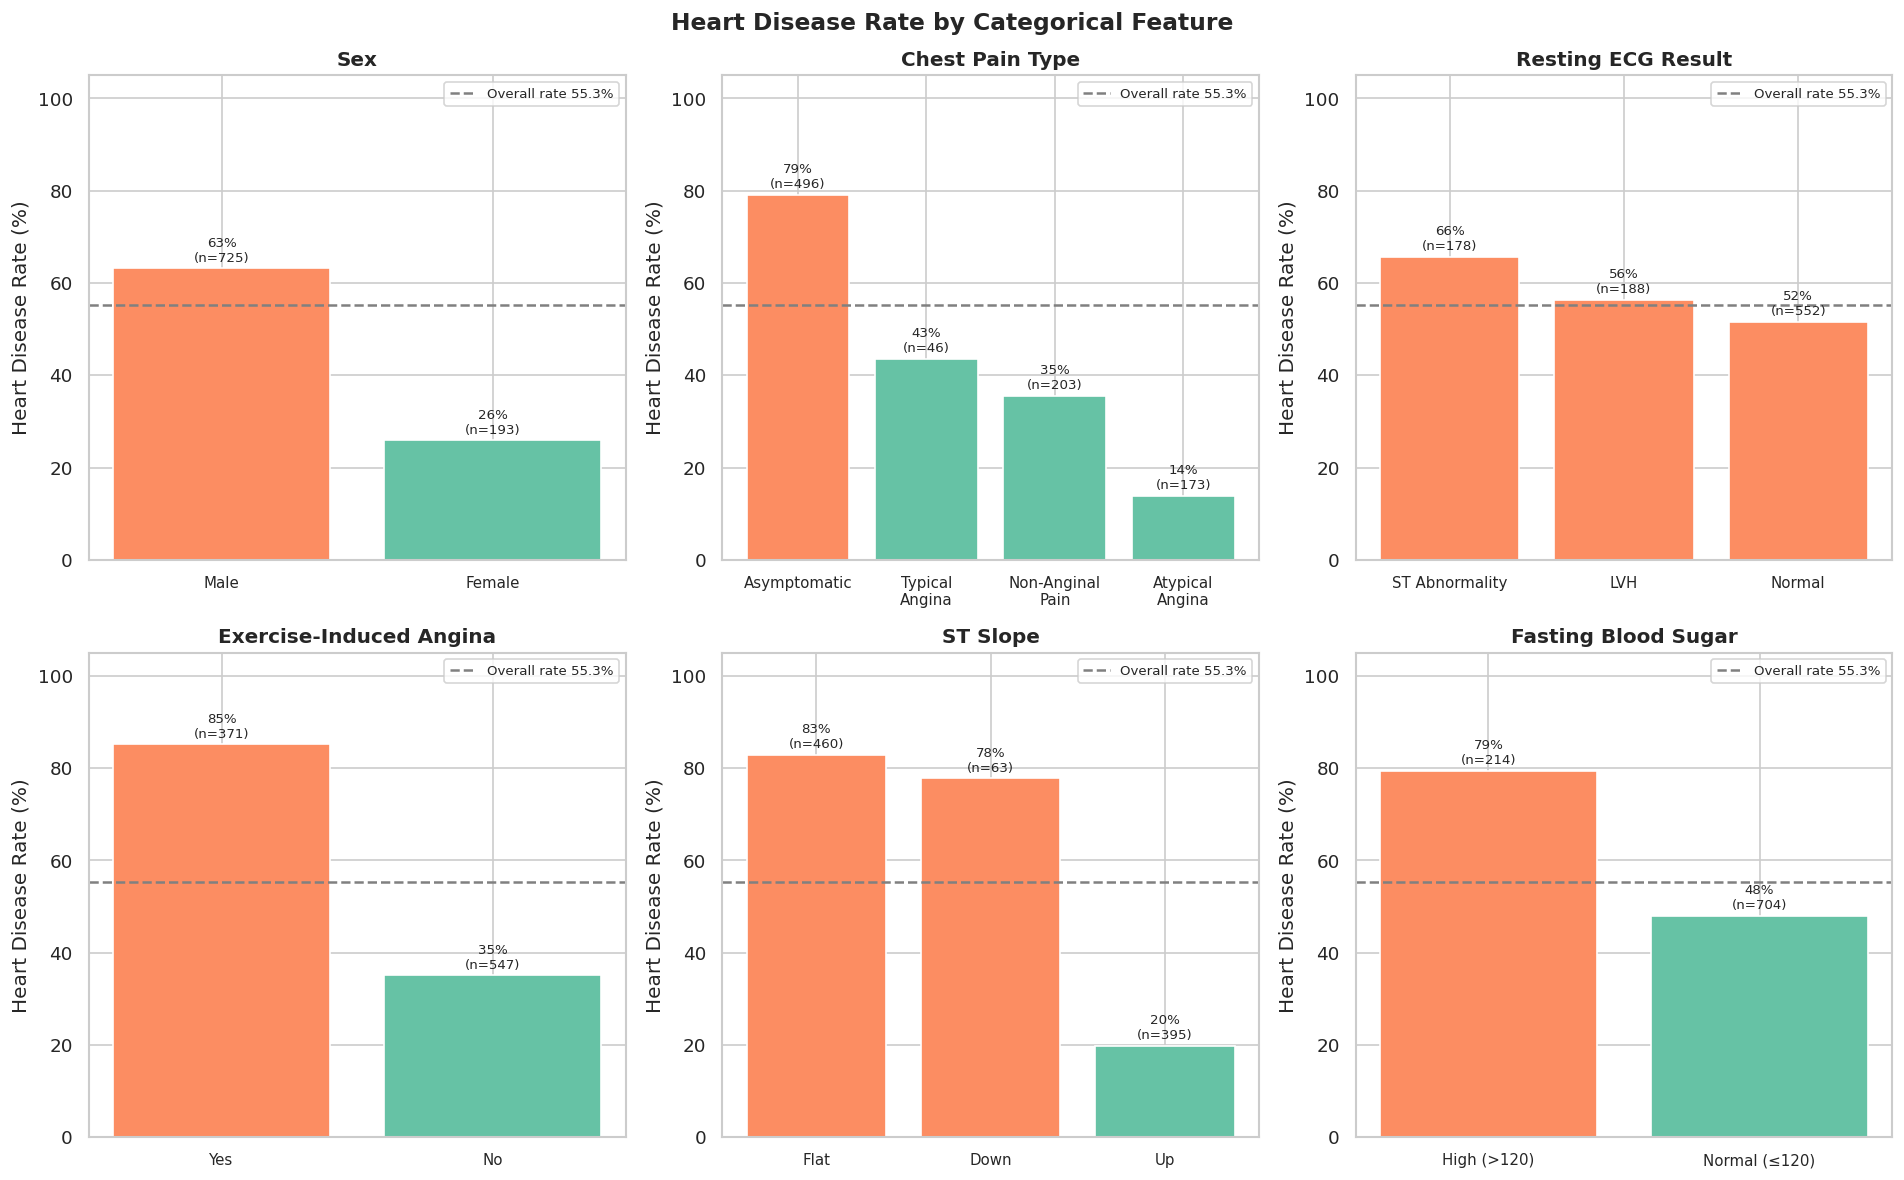

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Disease rate per category
    rate = df.groupby(col)['HeartDisease'].agg(['mean', 'count']).reset_index()
    rate.columns = [col, 'DisRate', 'Count']
    rate = rate.sort_values('DisRate', ascending=False)
    
    colors = [PALETTE[1] if r > 0.5 else PALETTE[0] for r in rate['DisRate']]
    bars = axes[i].bar(range(len(rate)), rate['DisRate'] * 100, color=colors, edgecolor='white')
    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels([cat_labels[col].get(k, str(k)) for k in rate[col]], fontsize=9)
    axes[i].set_title(cat_titles[col], fontweight='bold')
    axes[i].set_ylabel('Heart Disease Rate (%)')
    axes[i].axhline(55.3, color='gray', lw=1.5, linestyle='--', label='Overall rate 55.3%')
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(0, 105)
    for bar, (_, row) in zip(bars, rate.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                     f'{row["DisRate"]*100:.0f}%\n(n={int(row["Count"])})', 
                     ha='center', fontsize=8)

fig.suptitle('Heart Disease Rate by Categorical Feature', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()



- Chest Pain Type: Asymptomatic (ASY) patients have an 80% heart disease rate. Typical angina (TA) patients have only a 28% rate.
- ST Slope: Flat and Downward slopes are strongly associated with disease (76% and 79%). Upsloping ST is generally benign (23%).
- Exercise Angina: 83% of those with exercise-induced angina have heart disease vs. 40% of those without.
- Sex: Male patients have a 63% disease rate vs. 26% for females.
- Fasting Blood Sugar: Elevated blood sugar  is linked to 68% heart disease rate vs. 52% for normal.

## 7. Multivariate analysis

### 7.1 Correlation heatmap (Numeric features)

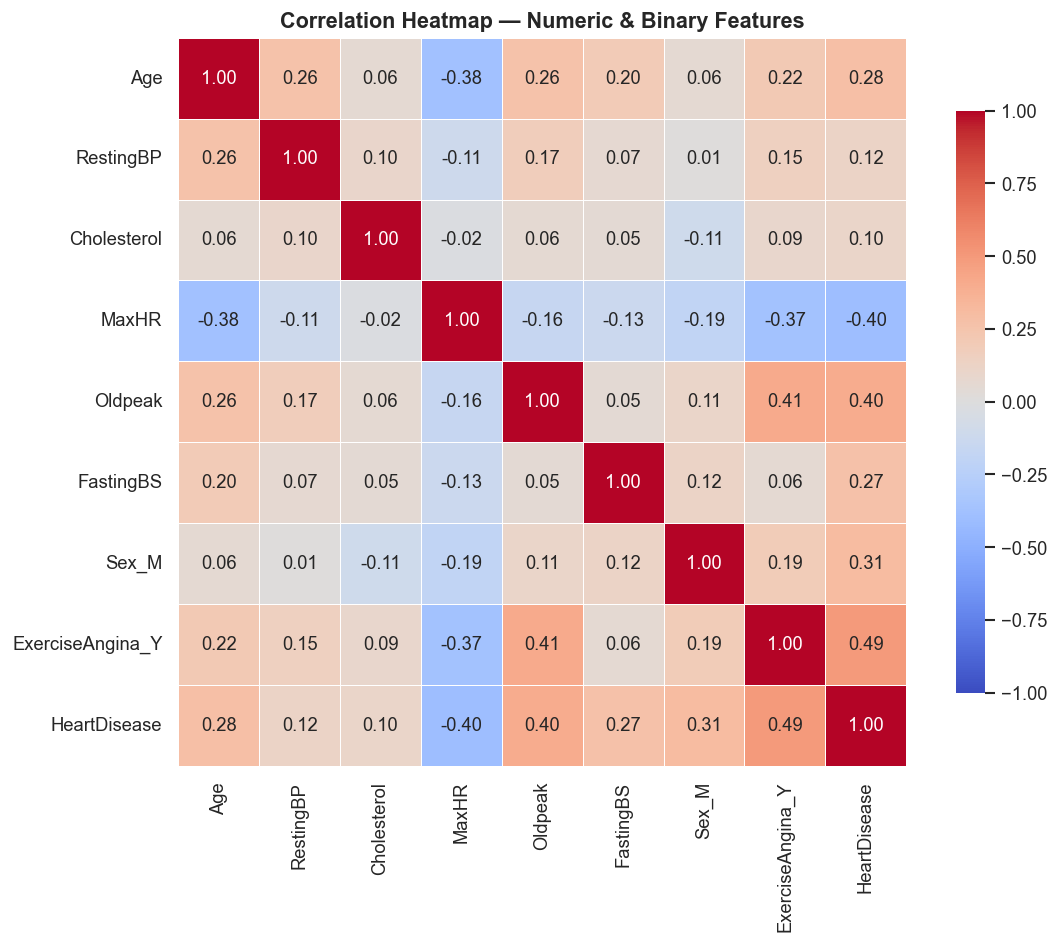


Correlations with HeartDisease (sorted by absolute value):
ExerciseAngina_Y    0.494
Oldpeak             0.404
MaxHR              -0.400
Sex_M               0.305
Age                 0.282
FastingBS           0.267
RestingBP           0.118
Cholesterol         0.104
Name: HeartDisease, dtype: float64


In [19]:
df_enc = df_clean.copy()
df_enc['Sex_M']          = (df_enc['Sex'] == 'M').astype(int)
df_enc['ExerciseAngina_Y'] = (df_enc['ExerciseAngina'] == 'Y').astype(int)
df_enc = pd.get_dummies(df_enc, columns=['ChestPainType', 'ST_Slope'], drop_first=False)
df_enc = df_enc.drop(columns=['Sex', 'ExerciseAngina', 'RestingECG'])

corr_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
             'FastingBS', 'Sex_M', 'ExerciseAngina_Y', 'HeartDisease']

corr = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric & Binary Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

target_corr = corr['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
print('\nCorrelations with HeartDisease (sorted by absolute value):')
print(target_corr.round(3))

### 7.2 Key relationship: Age × MaxHR × Disease

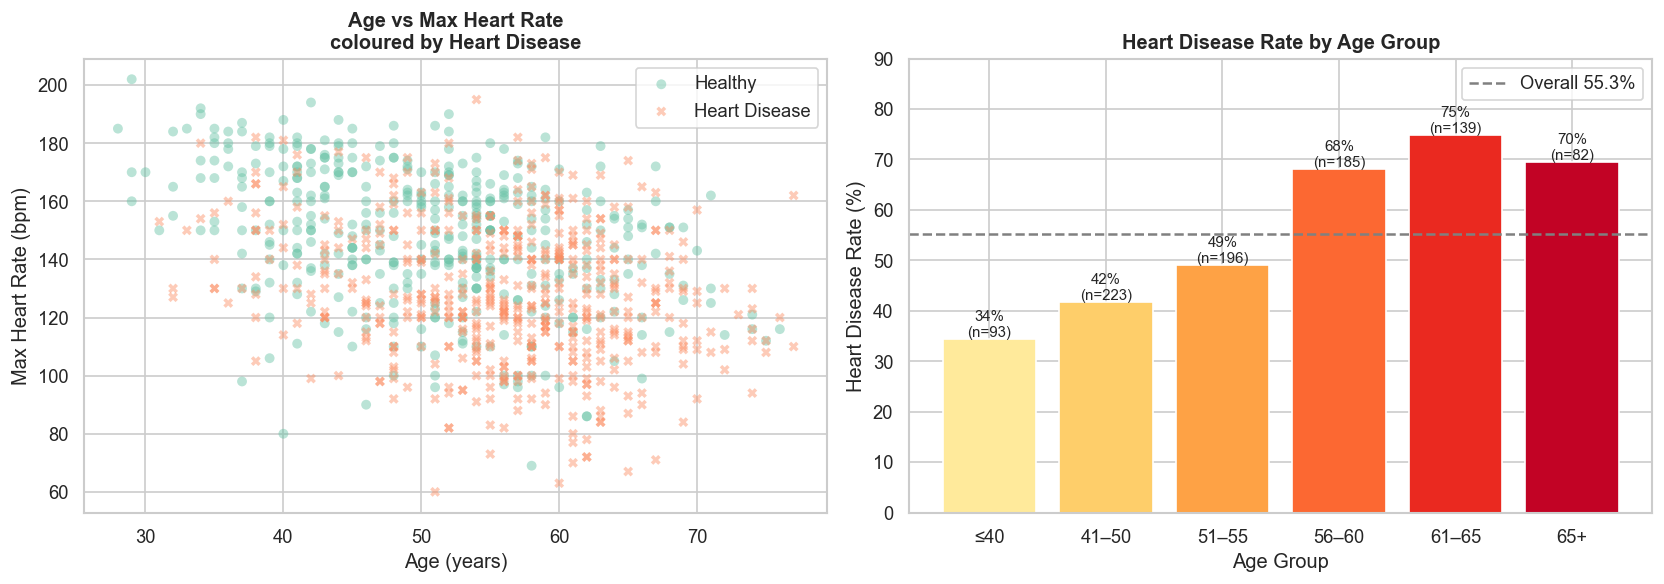

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hd, label, color, marker in zip([0, 1], ['Healthy', 'Heart Disease'], PALETTE, ['o', 'X']):
    sub = df[df['HeartDisease'] == hd]
    axes[0].scatter(sub['Age'], sub['MaxHR'], alpha=0.45, c=color,
                    label=label, s=35, marker=marker, edgecolors='none')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Max Heart Rate (bpm)')
axes[0].set_title('Age vs Max Heart Rate\ncoloured by Heart Disease', fontweight='bold')
axes[0].legend()

df_temp = df.copy()
df_temp['AgeBin'] = pd.cut(df_temp['Age'], bins=[20, 40, 50, 55, 60, 65, 80],
                            labels=['≤40', '41–50', '51–55', '56–60', '61–65', '65+'])
age_rate = df_temp.groupby('AgeBin', observed=True)['HeartDisease'].agg(['mean', 'count'])

bars = axes[1].bar(range(len(age_rate)), age_rate['mean'] * 100,
                   color=sns.color_palette('YlOrRd', len(age_rate)), edgecolor='white')
axes[1].set_xticks(range(len(age_rate)))
axes[1].set_xticklabels(age_rate.index)
axes[1].set_ylabel('Heart Disease Rate (%)')
axes[1].set_xlabel('Age Group')
axes[1].set_title('Heart Disease Rate by Age Group', fontweight='bold')
axes[1].axhline(55.3, color='gray', lw=1.5, linestyle='--', label='Overall 55.3%')
axes[1].legend()
for bar, (_, row) in zip(bars, age_rate.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{row["mean"]*100:.0f}%\n(n={int(row["count"])})', ha='center', fontsize=9)
axes[1].set_ylim(0, 90)

plt.tight_layout()
plt.show()

The scatter plot shows a clear pattern, where heart disease patients cluster at lower MaxHR values across all ages, this separation grows more pronounced at older ages. This confirms that the maximum heart rate achieved during exercise is one of the most informative features.

### 7.3 Oldpeak × ST_Slope

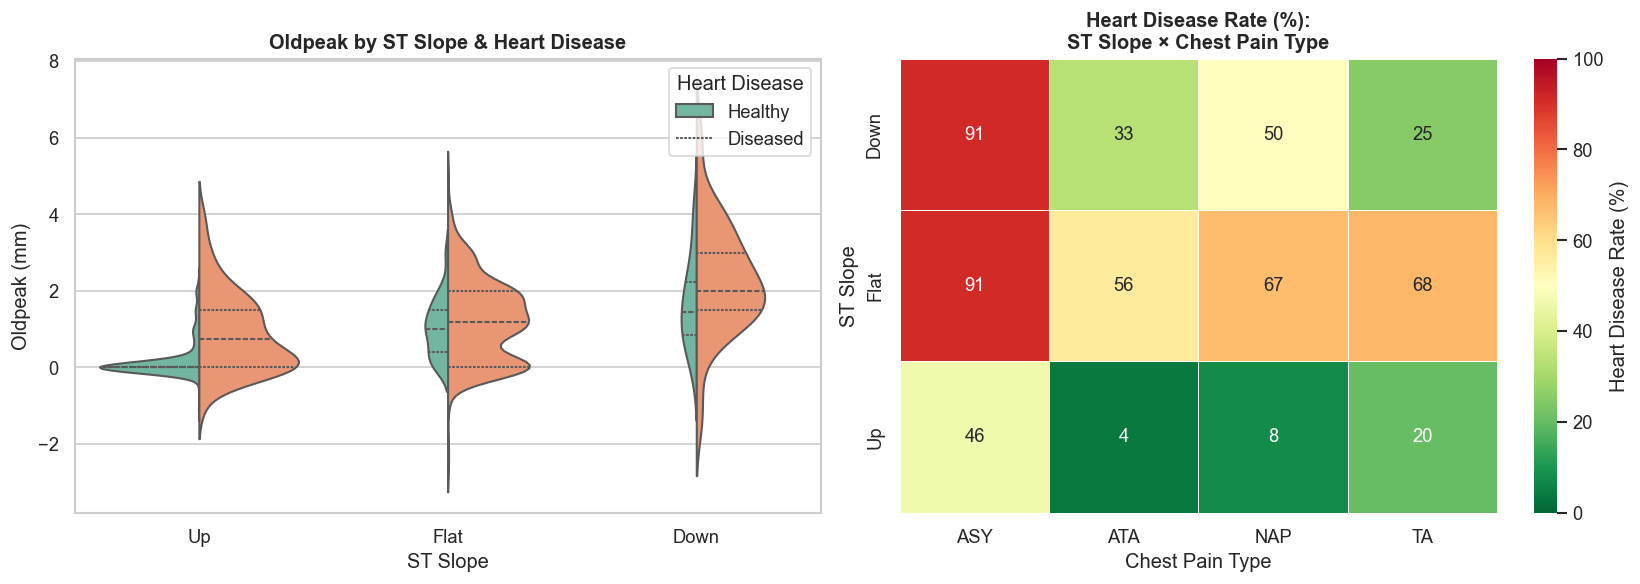

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Up', 'Flat', 'Down']
sns.violinplot(data=df, x='ST_Slope', y='Oldpeak', hue='HeartDisease',
               split=True, palette=PALETTE, order=order, ax=axes[0], inner='quart')
axes[0].set_title('Oldpeak by ST Slope & Heart Disease', fontweight='bold')
axes[0].set_xlabel('ST Slope')
axes[0].set_ylabel('Oldpeak (mm)')
axes[0].legend(title='Heart Disease', labels=['Healthy', 'Diseased'])

pivot = df.groupby(['ST_Slope', 'ChestPainType'])['HeartDisease'].mean().unstack() * 100
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=100, ax=axes[1],
            cbar_kws={'label': 'Heart Disease Rate (%)'},
            linewidths=0.5)
axes[1].set_title('Heart Disease Rate (%):\nST Slope × Chest Pain Type', fontweight='bold')
axes[1].set_xlabel('Chest Pain Type')
axes[1].set_ylabel('ST Slope')

plt.tight_layout()
plt.show()

The combination of Flat ST slope + Asymptomatic chest pain results into 90%+ heart disease rate in this dataset. In contrast, upsloping ST + atypical angina is the lowest-risk combination.
### 7.4 Pairplot

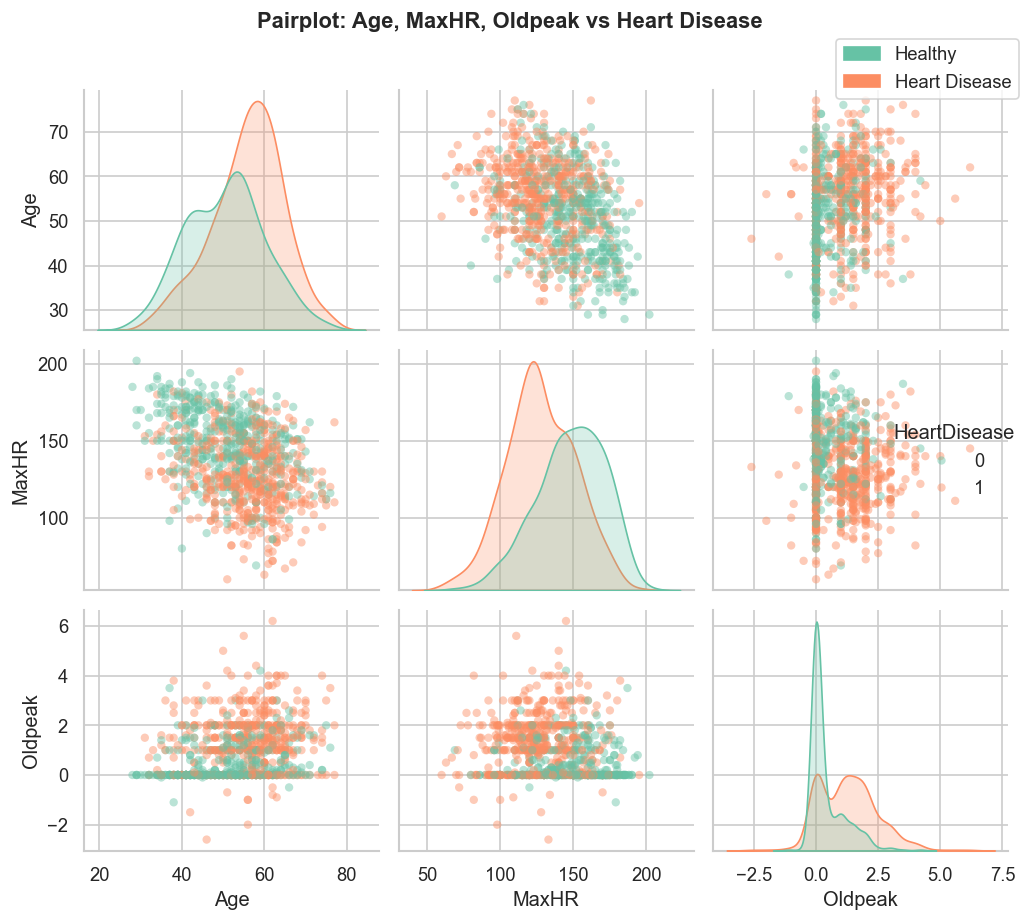

In [28]:
top_features = ['Age', 'MaxHR', 'Oldpeak', 'HeartDisease']
g = sns.pairplot(df[top_features], hue='HeartDisease', palette=PALETTE,
                 plot_kws=dict(alpha=0.45, s=25, edgecolors='none'),
                 diag_kind='kde')
g.figure.suptitle('Pairplot: Age, MaxHR, Oldpeak vs Heart Disease', y=1.02, fontweight='bold')
handles = [mpatches.Patch(color=PALETTE[0], label='Healthy'),
           mpatches.Patch(color=PALETTE[1], label='Heart Disease')]
g.figure.legend(handles=handles, loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

The pairplot confirms that the MaxHR-Oldpeak space shows the best linear separation between healthy and diseased patients.

### 7.5 Feature importance preview

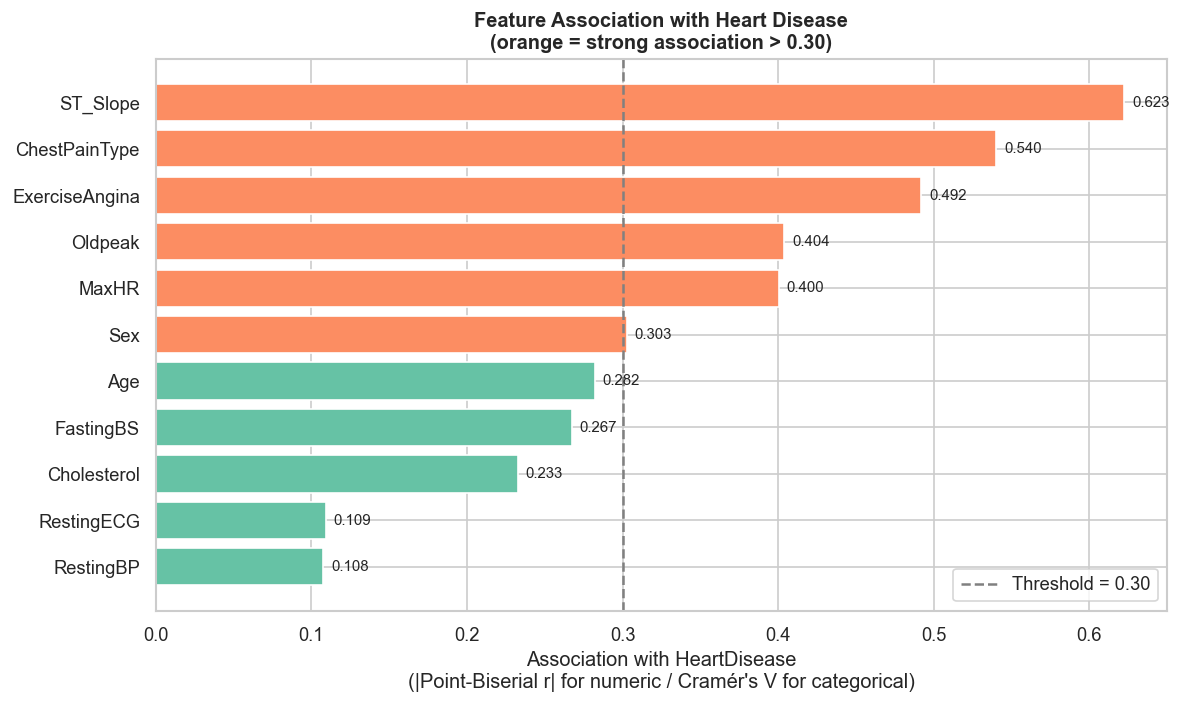

In [22]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

associations = {}
for col in num_features + ['FastingBS']:
    corr_val, _ = stats.pointbiserialr(df[col].fillna(df[col].median()), df['HeartDisease'])
    associations[col] = abs(corr_val)

for col in ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
    associations[col] = cramers_v(df[col], df['HeartDisease'])

assoc_series = pd.Series(associations).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#fc8d62' if v > 0.3 else '#66c2a5' for v in assoc_series.values]
bars = ax.barh(assoc_series.index, assoc_series.values, color=colors, edgecolor='white')
ax.axvline(0.3, color='gray', lw=1.5, linestyle='--', label='Threshold = 0.30')
ax.set_xlabel('Association with HeartDisease\n(|Point-Biserial r| for numeric / Cramér\'s V for categorical)')
ax.set_title('Feature Association with Heart Disease\n(orange = strong association > 0.30)', fontweight='bold')
for bar, val in zip(bars, assoc_series.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.legend()
ax.set_xlim(0, 0.65)
plt.tight_layout()
plt.show()

## 8. Feature engineering

Based on the EDA findings, following transformations before training a predictive model can be done:

In [26]:
recommendations = {
    'Issue': [
        'Cholesterol zeros (hidden missing)',
        'RestingBP zero (1 record)',
        'Cholesterol right-skew & outliers',
        'Oldpeak right-skew',
        'Categorical encoding needed',
        'ST_Slope × ChestPainType interaction',
        'Age × MaxHR interaction',
        'Class imbalance (55/45 split)',
        'Sex imbalance in dataset',
    ],
    'Recommended Action': [
        'Imputing with median per sex/age group (avoiding naive global median)',
        'Imputing with median or removing the single record',
        'Applying log-transformion or capping at 99th percentile (560 mm/dl)',
        'Applying log1p transformation (log(1 + Oldpeak))',
        'One-hot encoding: ChestPainType, ST_Slope, RestingECG; binary: Sex, ExerciseAngina',
        'Creating interaction feature: ST_Slope_ChestPainType combo or target-encode',
        'Creating MaxHR_Age_ratio = MaxHR / Age as a physiological index',
        'Using stratified splits; evaluating with AUC-ROC and F1; considering SMOTE if needed',
        'Reporting sex-stratified metrics to detect bias in model performance',
    ],
}

rec_df = pd.DataFrame(recommendations)
print('Feature Engineering Recommendations:')
print(rec_df.to_string(index=False))

Feature Engineering Recommendations:
                               Issue                                                                   Recommended Action
  Cholesterol zeros (hidden missing)                Imputing with median per sex/age group (avoiding naive global median)
           RestingBP zero (1 record)                                   Imputing with median or removing the single record
   Cholesterol right-skew & outliers                  Applying log-transformion or capping at 99th percentile (560 mm/dl)
                  Oldpeak right-skew                                     Applying log1p transformation (log(1 + Oldpeak))
         Categorical encoding needed   One-hot encoding: ChestPainType, ST_Slope, RestingECG; binary: Sex, ExerciseAngina
ST_Slope × ChestPainType interaction          Creating interaction feature: ST_Slope_ChestPainType combo or target-encode
             Age × MaxHR interaction                      Creating MaxHR_Age_ratio = MaxHR / Age as a physiol

## 9. Conclusions

This exploratory analysis of the Heart Failure Prediction dataset shows a largely well-structured dataset with a few important caveats. Here is a summary of the key findings:


### Data quality
- No structural NaN values found, but Cholesterol contains 172 zero values (18.7%) that represent missing measurements,these must be imputed carefully before modelling.
- One impossible RestingBP = 0 record should be removed or imputed.
- Outliers exist (notably high Cholesterol and Oldpeak), but most are medically plausible and should be log-transformed rather than deleted.

### Key predictors
The features most strongly associated with heart disease are:

1. ST_Slope - flat or downward slope is the strongest single predictor (~0.51 Cramér's V)
2. ExerciseAngina - pain during exercise is a near-definitive warning sign (~0.47)
3. ChestPainType - asymptomatic presentation is paradoxically the most dangerous (~0.46)
4. MaxHR - lower maximum heart rate is strongly linked to disease (~0.42)
5. Oldpeak - greater ST depression during exercise signals ischemia (~0.41)
6. Sex - males have significantly higher disease rates in this dataset
7. Age - risk increases substantially after age 55

### Biases
- The dataset is heavily male-skewed (79% male).
- Cholesterol behaves counterintuitively (diseased patients have slightly lower mean cholesterol).
- The dataset is a combination of 5 separate studies with different collection protocols, it may introduce batch effects.

### Modelling recommendations
- Better to use AUC-ROC and F1-score as primary metrics, given the mild class imbalance.
- Appling stratified cross-validation possible to preserve the target ratio across folds.
- Random Forest, XGBoost can be used further given the mix of numeric and categorical features.
